## ⚠️ Dependency Note
> This notebook depends on variables produced by the preprocessing and PCA notebooks.
> Ensure , , and  are available before running.
> Input: 

# 🔬 MADELON Dataset — Unsupervised Learning Pipeline
### K-Means · Hierarchical Clustering · DBSCAN · PCA
---
| | |
|---|---|
| **Dataset** | MADELON (UCI ML Repository) |
| **Samples** | 2,600 (2,000 train + 600 validation) |
| **Features** | 500 numeric features |
| **Ground Truth** | Binary labels: +1 / -1 |
| **Algorithms** | K-Means, Hierarchical, DBSCAN |
| **Dimensionality Reduction** | PCA |
---

## 📦 Step 0 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
# Load PCA-transformed data (output from dev/pca branch)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score)
from scipy.cluster.hierarchy import dendrogram, linkage

X_pca = pd.read_csv("data/processed/madelon_pca.csv").values
X_2d  = pd.read_csv("data/processed/madelon_pca2d.csv").values
y_all = pd.read_csv("data/processed/madelon_labels.csv").squeeze()

print(f"X_pca shape: {X_pca.shape}")
print(f"X_2d  shape: {X_2d.shape}")
print("✅ Data loaded successfully")

---
## 🌳 Step 6 — Hierarchical Clustering

**How Hierarchical works:** Starts with each point as its own cluster, then merges the two closest clusters repeatedly until one cluster remains. We cut the tree at our desired number of clusters.

**Hyperparameters:** `n_clusters` and `linkage` (how distance between clusters is measured):
- **Ward:** minimises variance within clusters
- **Complete:** uses maximum distance between points
- **Average:** uses average distance between all points

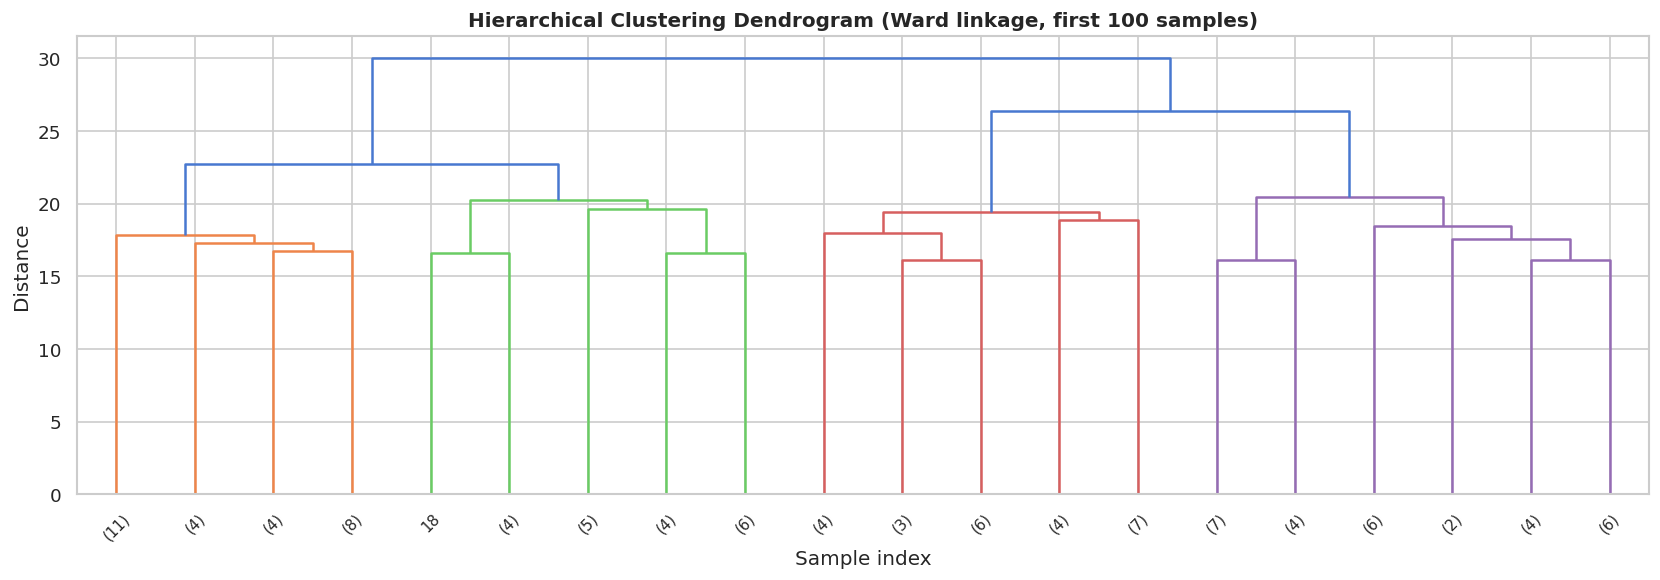

In [ ]:
# Dendrogram — visualise the merging process
from scipy.cluster.hierarchy import dendrogram, linkage

X_sub = X_pca[:100]   # subset for readability
Z = linkage(X_sub, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=9)
ax.set_title('Dendrogram (Ward linkage, first 100 samples)', fontweight='bold')
ax.set_xlabel('Sample index'); ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
# Try all three linkage methods
linkages = ['ward', 'complete', 'average']
hc_results = {}

for link in linkages:
    hc = AgglomerativeClustering(n_clusters=2, linkage=link)
    lbl = hc.fit_predict(X_pca)
    hc_results[link] = {
        'labels': lbl,
        'sil': silhouette_score(X_pca, lbl),
        'dbi': davies_bouldin_score(X_pca, lbl),
        'chi': calinski_harabasz_score(X_pca, lbl),
        'ari': adjusted_rand_score(y_all, lbl),
        'nmi': normalized_mutual_info_score(y_all, lbl)
    }

print("=== Hierarchical Clustering — Linkage Comparison ===")
print(f"{'Linkage':<12} {'Silhouette':>12} {'DBI':>8} {'ARI':>8}")
print("-" * 42)
for link in linkages:
    r = hc_results[link]
    print(f"{link:<12} {r['sil']:>12.4f} {r['dbi']:>8.4f} {r['ari']:>8.4f}")

best_link = max(hc_results, key=lambda x: hc_results[x]['sil'])
print(f"\n✅ Best linkage: {best_link}")

=== Hierarchical Clustering — Linkage Comparison ===
Linkage        Silhouette      DBI      ARI
------------------------------------------
ward               0.0265   5.7737   0.0060
complete           0.0224   6.3368   0.0030
average            0.1489   1.3666   0.0000

✅ Best linkage: average


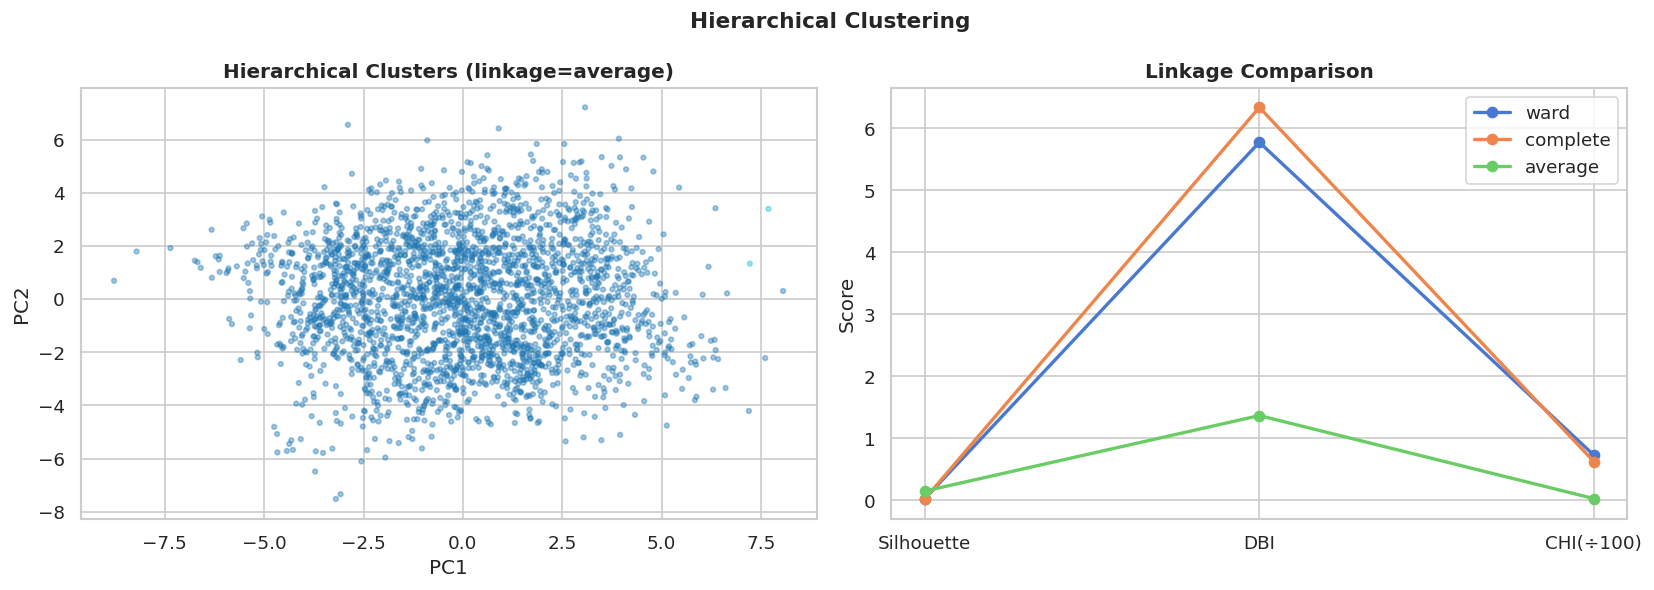

In [ ]:
# Visualise best hierarchical clustering
hc_labels = hc_results[best_link]['labels']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_2d[:,0], X_2d[:,1], c=hc_labels,
                cmap='tab10', alpha=0.4, s=8)
axes[0].set_title(f'Hierarchical Clusters (linkage={best_link})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

for link in linkages:
    axes[1].plot(['Silhouette','DBI','CHI(÷100)'],
                 [hc_results[link]['sil'], hc_results[link]['dbi'],
                  hc_results[link]['chi']/100],
                 marker='o', label=link, linewidth=2)
axes[1].set_title('Linkage Method Comparison', fontweight='bold')
axes[1].legend(); axes[1].set_ylabel('Score')

plt.suptitle('Hierarchical Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()